# Importando Bibliotecas

In [335]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

# Abrindo os dados

In [338]:
# Caminho para o arquivo Parquet
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\TODAS_ESTACOES_CONCATENADO.parquet"

# Ler o arquivo Parquet
df = pd.read_parquet(caminho_parquet)

In [340]:
df.head(1)

,Dt_Hr,timestamp,Lat,Long,Alt,Precip,Pres_Atm,Pres_Atm_max,Pres_Atm_min,Rad,...,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE,VARIACAO TERCEIRA HORA ANTERIOR UMIDAD,DIRECAO DO VENTO PRIMEIRA HORA ANTERIOR,DIRECAO DO VENTO SEGUNDA HORA ANTERIOR,DIRECAO DO VENTO TERCEIRA HORA ANTERIOR,DIRECAO DO VENTO QUARTA HORA ANTERIOR,DIRECAO DO VENTO QUINTA HORA ANTERIOR,DIRECAO DO VENTO SEXTA HORA ANTERIOR
0,2007-05-18,1.179457e+09,-22.988333,-43.190278,42.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [342]:
df.columns

Index(['Dt_Hr', 'timestamp', 'Lat', 'Long', 'Alt', 'Precip', 'Pres_Atm',
       'Pres_Atm_max', 'Pres_Atm_min', 'Rad', 'Temp_Amb', 'Pto_Orv',
       'Temp_Amb_max', 'Temp_Amb_min', 'Pto_Orv_max', 'Pto_Orv_min',
       'Umidade_max', 'Umidade_min', 'Umidade', 'Vento_dir', 'Vento_raj',
       'Vento_vel', 'ESTACAO', 'estacao_do_ano', 'hora', 'turno',
       'PRECIPITAÇÃO TOTAL primeira hora anterior',
       'PRECIPITAÇÃO TOTAL segunda hora anterior',
       'PRECIPITAÇÃO TOTAL terceira hora anterior',
       'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO',
       'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO',
       'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO',
       'VARIACAO QUARTA HORA ANTERIOR PRESSAO',
       'VARIACAO QUINTA HORA ANTERIOR PRESSAO',
       'VARIACAO SEXTA HORA ANTERIOR PRESSAO',
       'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
       'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA AMBIENTE',
       'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA AMBIENTE',
       'VARIAC

# Percentis

In [347]:
dados_de_precipitacao = df[(df['Precip'] > 0)]


In [349]:
percentis = np.arange(0, 101, 1)

valores_percentis = np.percentile(dados_de_precipitacao['Precip'], percentis)


In [363]:
df_percentis = pd.DataFrame({'Percentis de precipitação': percentis, 'Valor': valores_percentis})
# pd.set_option('display.max_rows', None)

print(df_percentis)


     Percentis de precipitação  Valor
0                            0    0.2
1                            1    0.2
2                            2    0.2
3                            3    0.2
4                            4    0.2
5                            5    0.2
6                            6    0.2
7                            7    0.2
8                            8    0.2
9                            9    0.2
10                          10    0.2
11                          11    0.2
12                          12    0.2
13                          13    0.2
14                          14    0.2
15                          15    0.2
16                          16    0.2
17                          17    0.2
18                          18    0.2
19                          19    0.2
20                          20    0.2
21                          21    0.2
22                          22    0.2
23                          23    0.2
24                          24    0.2
25          

In [357]:
dados_de_precipitacao['Precip'].describe()

count    43704.000000
mean         1.657253
std          3.590490
min          0.200000
25%          0.200000
50%          0.600000
75%          1.600000
max         97.200000
Name: Precip, dtype: float64

In [373]:
percentis = np.arange(0, 100, 0.05)

valores_percentis = np.percentile(dados_de_precipitacao['Precip'], percentis)

In [375]:
df_percentis = pd.DataFrame({'Percentis de precipitação': percentis, 'Valor': valores_percentis})
# pd.set_option('display.max_rows', None)

print(df_percentis)

      Percentis de precipitação    Valor
0                          0.00   0.2000
1                          0.05   0.2000
2                          0.10   0.2000
3                          0.15   0.2000
4                          0.20   0.2000
5                          0.25   0.2000
6                          0.30   0.2000
7                          0.35   0.2000
8                          0.40   0.2000
9                          0.45   0.2000
10                         0.50   0.2000
11                         0.55   0.2000
12                         0.60   0.2000
13                         0.65   0.2000
14                         0.70   0.2000
15                         0.75   0.2000
16                         0.80   0.2000
17                         0.85   0.2000
18                         0.90   0.2000
19                         0.95   0.2000
20                         1.00   0.2000
21                         1.05   0.2000
22                         1.10   0.2000
23              

# Distribuição de chuva. 

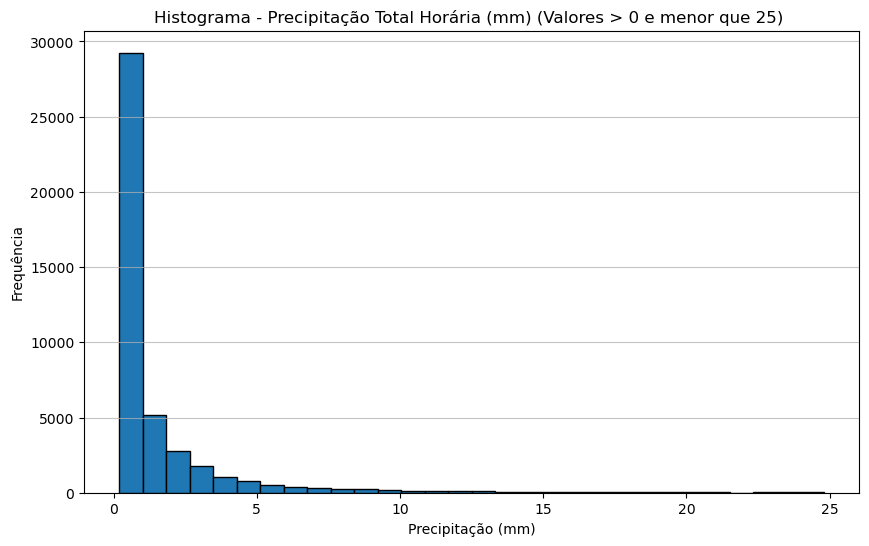

In [280]:
# Gráfico da distribuição de chuva. 

dados_chuva = df[(df['Precip'] > 0) & (df['Precip'] < 25)]
    
plt.figure(figsize=(10, 6))
plt.hist(dados_chuva['Precip'], bins=30, edgecolor='black')
plt.title('Histograma - Precipitação Total Horária (mm) (Valores > 0 e menor que 25) ')
plt.xlabel('Precipitação (mm)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

Parâmetros da Log-Normal:
 - shape (σ): 18.1226
 - loc (μ deslocado): 0.2000
 - scale (exp(μ)): 0.0000


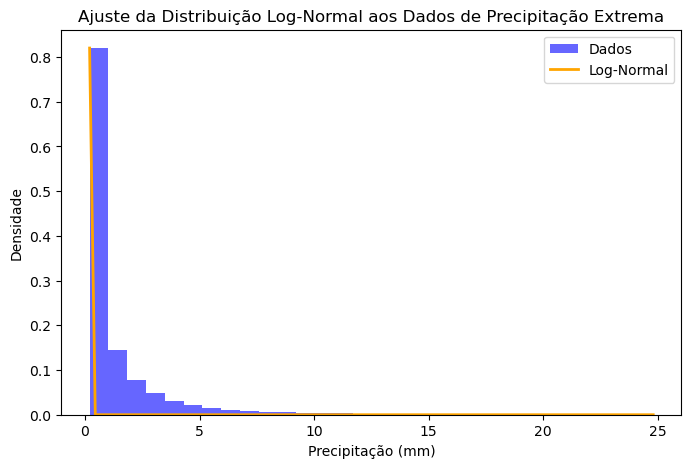

Teste KS para Log-Normal: KS=0.3935, p-valor=0.0000


In [281]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Carregar os dados de precipitação
dados = dados_chuva['Precip']

# Ajustar distribuição Log-Normal
dist = stats.lognorm
params = dist.fit(dados)  # Ajuste dos parâmetros
shape, loc, scale = params  # Parâmetros da distribuição

# Exibir os parâmetros ajustados
print(f"Parâmetros da Log-Normal:")
print(f" - shape (σ): {shape:.4f}")
print(f" - loc (μ deslocado): {loc:.4f}")
print(f" - scale (exp(μ)): {scale:.4f}")

# Criar histograma normalizado
plt.figure(figsize=(8, 5))
contagem, bins, _ = plt.hist(dados, bins=30, density=True, alpha=0.6, color='b', label='Dados')

# Gerar valores da PDF
x = np.linspace(min(dados), max(dados), 100)
pdf = dist.pdf(x, *params)

# Ajustar escala da PDF para o histograma
pdf *= max(contagem) / max(pdf)

# Plotar curva ajustada
plt.plot(x, pdf, color='orange', lw=2, label='Log-Normal')

plt.xlabel("Precipitação (mm)")
plt.ylabel("Densidade")
plt.legend()
plt.title("Ajuste da Distribuição Log-Normal aos Dados de Precipitação Extrema")
plt.show()

# Teste de Kolmogorov-Smirnov para Log-Normal
ks_stat, p_value = stats.kstest(dados, 'lognorm', args=params)
print(f"Teste KS para Log-Normal: KS={ks_stat:.4f}, p-valor={p_value:.4f}")

In [282]:
# Estatística da distribuição de chuva. 
dados_chuva['Precip'].describe()

count    43505.000000
mean         1.497570
std          2.597013
min          0.200000
25%          0.200000
50%          0.600000
75%          1.600000
max         24.800000
Name: Precip, dtype: float64

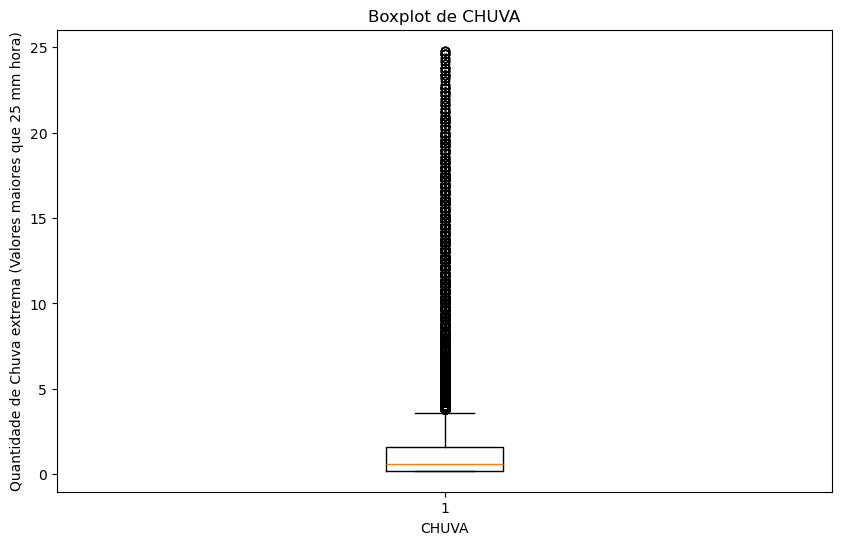

In [283]:
# Criar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(dados_chuva['Precip'])
plt.title('Boxplot de CHUVA')
plt.ylabel('Quantidade de Chuva extrema (Valores maiores que 25 mm hora)')
plt.xlabel('CHUVA')
plt.show()


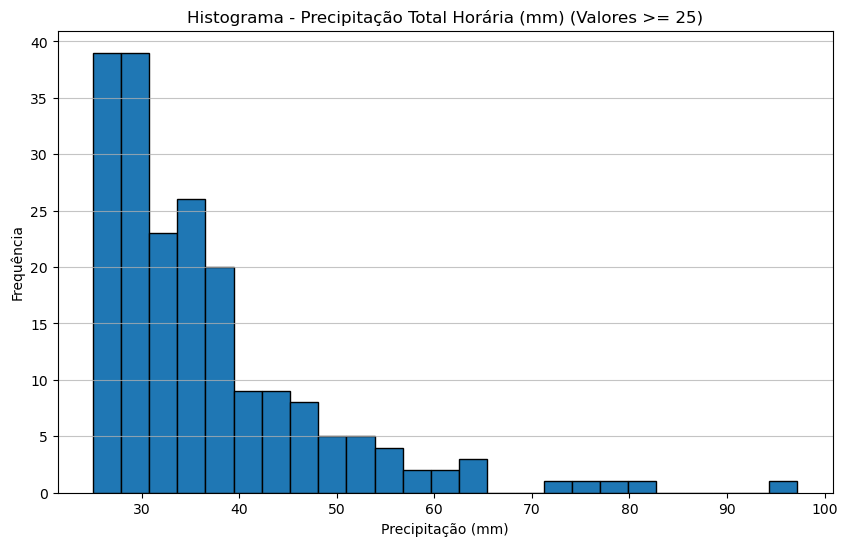

In [284]:
# Gráfico da distribuição de chuva extrema, maior que 25 mm hora 

dados_chuva_extrema = df[df['Precip'] >= 25]

plt.figure(figsize=(10, 6))



plt.hist(dados_chuva_extrema['Precip'], bins=25, edgecolor='black')
plt.title('Histograma - Precipitação Total Horária (mm) (Valores >= 25)')
plt.xlabel('Precipitação (mm)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

Parâmetros da Log-Normal:
 - shape (σ): 0.9041
 - loc (μ deslocado): 23.9744
 - scale (exp(μ)): 8.6279


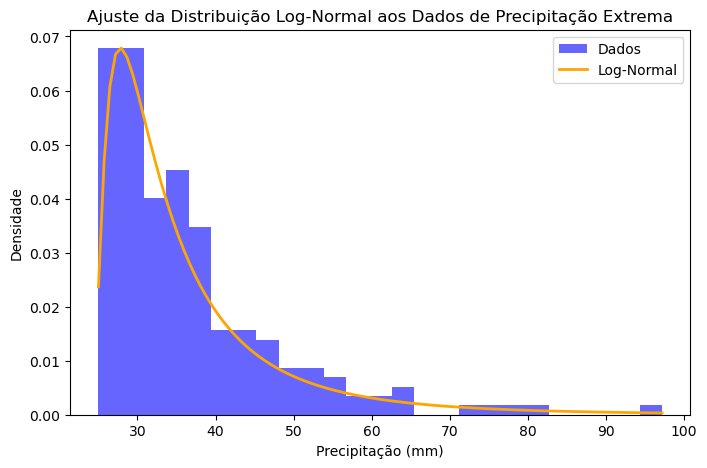

Teste KS para Log-Normal: KS=0.0507, p-valor=0.6671


In [285]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Carregar os dados de precipitação
dados = dados_chuva_extrema['Precip']

# Ajustar distribuição Log-Normal
dist = stats.lognorm
params = dist.fit(dados)  # Ajuste dos parâmetros
shape, loc, scale = params  # Parâmetros da distribuição

# Exibir os parâmetros ajustados
print(f"Parâmetros da Log-Normal:")
print(f" - shape (σ): {shape:.4f}")
print(f" - loc (μ deslocado): {loc:.4f}")
print(f" - scale (exp(μ)): {scale:.4f}")

# Criar histograma normalizado
plt.figure(figsize=(8, 5))
contagem, bins, _ = plt.hist(dados, bins=25, density=True, alpha=0.6, color='b', label='Dados')

# Gerar valores da PDF
x = np.linspace(min(dados), max(dados), 100)
pdf = dist.pdf(x, *params)

# Ajustar escala da PDF para o histograma
pdf *= max(contagem) / max(pdf)

# Plotar curva ajustada
plt.plot(x, pdf, color='orange', lw=2, label='Log-Normal')

plt.xlabel("Precipitação (mm)")
plt.ylabel("Densidade")
plt.legend()
plt.title("Ajuste da Distribuição Log-Normal aos Dados de Precipitação Extrema")
plt.show()

# Teste de Kolmogorov-Smirnov para Log-Normal
ks_stat, p_value = stats.kstest(dados, 'lognorm', args=params)
print(f"Teste KS para Log-Normal: KS={ks_stat:.4f}, p-valor={p_value:.4f}")


Parâmetros da Gama:
 - shape (α): 0.8452
 - loc (μ deslocado): 25.0000
 - scale (θ): 12.8972


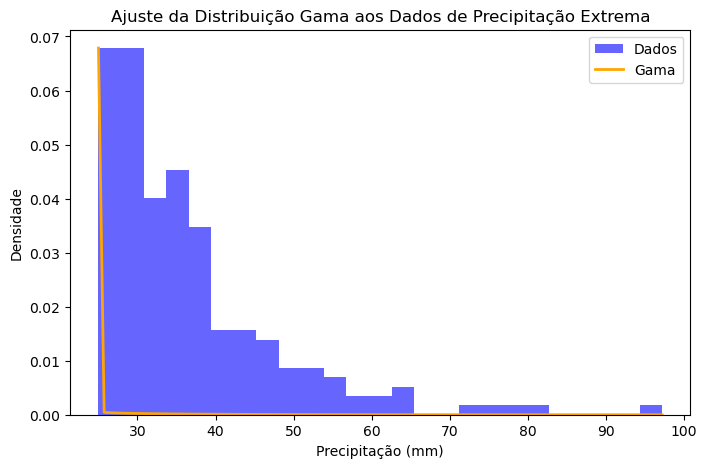

Teste KS para Gama: KS=0.0869, p-valor=0.0932


In [286]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Carregar os dados de precipitação
dados = dados_chuva_extrema['Precip']

# Ajustar distribuição Gama
dist = stats.gamma
params = dist.fit(dados)  # Ajuste dos parâmetros
shape, loc, scale = params  # Parâmetros da distribuição

# Exibir os parâmetros ajustados
print(f"Parâmetros da Gama:")
print(f" - shape (α): {shape:.4f}")
print(f" - loc (μ deslocado): {loc:.4f}")
print(f" - scale (θ): {scale:.4f}")

# Criar histograma normalizado
plt.figure(figsize=(8, 5))
contagem, bins, _ = plt.hist(dados, bins=25, density=True, alpha=0.6, color='b', label='Dados')

# Gerar valores da PDF
x = np.linspace(min(dados), max(dados), 100)
pdf = dist.pdf(x, *params)

# Ajustar escala da PDF para o histograma
pdf *= max(contagem) / max(pdf)

# Plotar curva ajustada
plt.plot(x, pdf, color='orange', lw=2, label='Gama')

plt.xlabel("Precipitação (mm)")
plt.ylabel("Densidade")
plt.legend()
plt.title("Ajuste da Distribuição Gama aos Dados de Precipitação Extrema")
plt.show()

# Teste de Kolmogorov-Smirnov para Gama
ks_stat, p_value = stats.kstest(dados, 'gamma', args=params)
print(f"Teste KS para Gama: KS={ks_stat:.4f}, p-valor={p_value:.4f}")


Parâmetros da Weibull:
 - shape (α): 0.9595
 - loc (μ deslocado): 25.0000
 - scale (λ): 11.6692


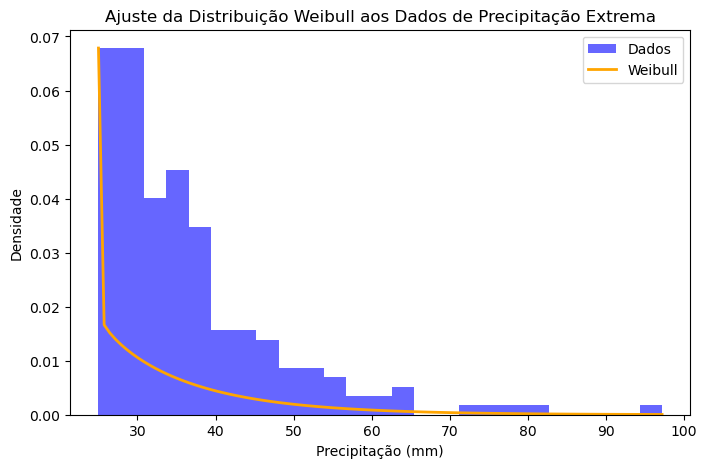

Teste KS para Weibull: KS=0.0472, p-valor=0.7492


In [287]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Carregar os dados de precipitação
dados = dados_chuva_extrema['Precip']

# Ajustar distribuição Weibull
dist = stats.weibull_min
params = dist.fit(dados)  # Ajuste dos parâmetros
shape, loc, scale = params  # Parâmetros da distribuição

# Exibir os parâmetros ajustados
print(f"Parâmetros da Weibull:")
print(f" - shape (α): {shape:.4f}")
print(f" - loc (μ deslocado): {loc:.4f}")
print(f" - scale (λ): {scale:.4f}")

# Criar histograma normalizado
plt.figure(figsize=(8, 5))
contagem, bins, _ = plt.hist(dados, bins=25, density=True, alpha=0.6, color='b', label='Dados')

# Gerar valores da PDF
x = np.linspace(min(dados), max(dados), 100)
pdf = dist.pdf(x, *params)

# Ajustar escala da PDF para o histograma
pdf *= max(contagem) / max(pdf)

# Plotar curva ajustada
plt.plot(x, pdf, color='orange', lw=2, label='Weibull')

plt.xlabel("Precipitação (mm)")
plt.ylabel("Densidade")
plt.legend()
plt.title("Ajuste da Distribuição Weibull aos Dados de Precipitação Extrema")
plt.show()

# Teste de Kolmogorov-Smirnov para Weibull
ks_stat, p_value = stats.kstest(dados, 'weibull_min', args=params)
print(f"Teste KS para Weibull: KS={ks_stat:.4f}, p-valor={p_value:.4f}")


In [288]:
dados_chuva_extrema['Precip'].describe()

count    199.000000
mean      36.566834
std       11.539213
min       25.000000
25%       28.800000
50%       33.600000
75%       40.000000
max       97.200000
Name: Precip, dtype: float64

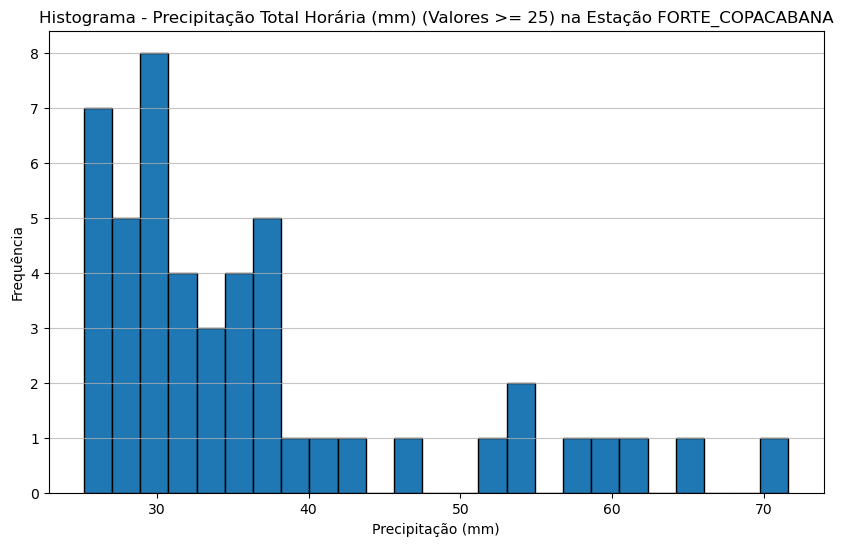

In [289]:
import matplotlib.pyplot as plt

# Filtrar dados para a estação "FORTE_COPACABANA" e precipitação >= 25
dados_chuva_extrema = df[(df['Precip'] >= 25) & (df['ESTACAO'] == 'FORTE_COPACABANA')]

# Criar o histograma com mais bins
plt.figure(figsize=(10, 6))
plt.hist(dados_chuva_extrema['Precip'], bins=25, edgecolor='black')  # Aumentei para 50 bins
plt.title('Histograma - Precipitação Total Horária (mm) (Valores >= 25) na Estação FORTE_COPACABANA')
plt.xlabel('Precipitação (mm)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()


Parâmetros da Log-Normal:
 - shape (σ): 0.9371
 - loc (μ deslocado): 24.4474
 - scale (exp(μ)): 8.2152


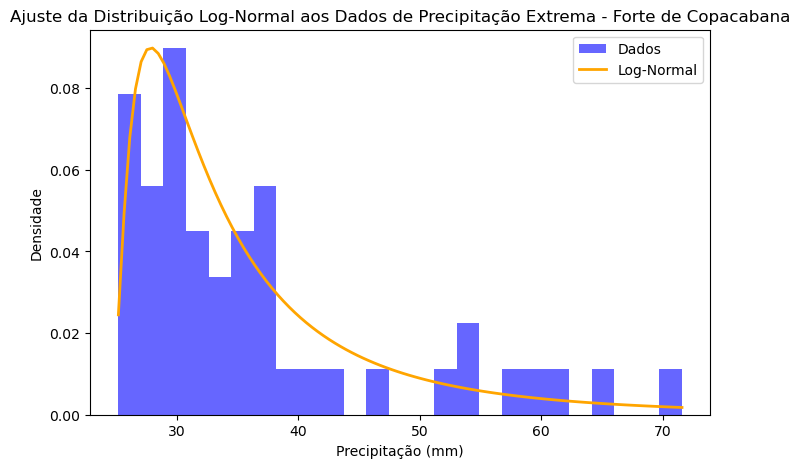

Teste KS para Log-Normal: KS=0.0726, p-valor=0.9459


In [290]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Selecionar os dados de precipitação
dados = dados_chuva_extrema['Precip']  # Certifique-se de que é uma série numérica
dados = dados.dropna()  # Remove valores NaN
dados = dados[np.isfinite(dados)]  # Remove valores infinitos

# Ajustar distribuição Log-Normal
dist = stats.lognorm
params = dist.fit(dados)  # Ajuste dos parâmetros
shape, loc, scale = params  # Parâmetros da distribuição

# Exibir os parâmetros ajustados
print(f"Parâmetros da Log-Normal:")
print(f" - shape (σ): {shape:.4f}")
print(f" - loc (μ deslocado): {loc:.4f}")
print(f" - scale (exp(μ)): {scale:.4f}")

# Criar histograma normalizado
plt.figure(figsize=(8, 5))
contagem, bins, _ = plt.hist(dados, bins=25, density=True, alpha=0.6, color='b', label='Dados')

# Gerar valores da PDF
x = np.linspace(min(dados), max(dados), 100)
pdf = dist.pdf(x, *params)

# Ajustar escala da PDF para o histograma
pdf *= max(contagem) / max(pdf)

# Plotar curva ajustada
plt.plot(x, pdf, color='orange', lw=2, label='Log-Normal')

plt.xlabel("Precipitação (mm)")
plt.ylabel("Densidade")
plt.legend()
plt.title("Ajuste da Distribuição Log-Normal aos Dados de Precipitação Extrema - Forte de Copacabana")
plt.show()

# Teste de Kolmogorov-Smirnov para Log-Normal
ks_stat, p_value = stats.kstest(dados, 'lognorm', args=params)
print(f"Teste KS para Log-Normal: KS={ks_stat:.4f}, p-valor={p_value:.4f}")


Parâmetros da Log-Normal:
 - shape (σ): 0.9292
 - loc (μ deslocado): 24.1026
 - scale (exp(μ)): 7.7095


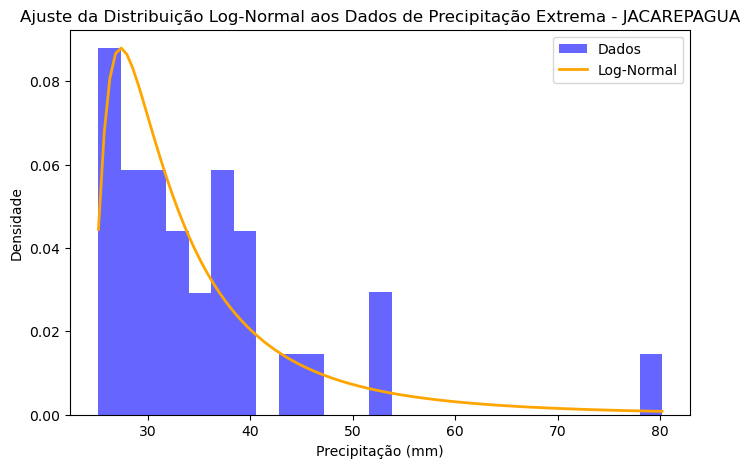

Teste KS para Log-Normal: KS=0.0925, p-valor=0.9312


In [291]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


dados_chuva_extrema = df[(df['Precip'] >= 25) & (df['ESTACAO'] == 'JACAREPAGUA')]


# Selecionar os dados de precipitação
dados = dados_chuva_extrema['Precip']  # Certifique-se de que é uma série numérica
dados = dados.dropna()  # Remove valores NaN
dados = dados[np.isfinite(dados)]  # Remove valores infinitos

# Ajustar distribuição Log-Normal
dist = stats.lognorm
params = dist.fit(dados)  # Ajuste dos parâmetros
shape, loc, scale = params  # Parâmetros da distribuição

# Exibir os parâmetros ajustados
print(f"Parâmetros da Log-Normal:")
print(f" - shape (σ): {shape:.4f}")
print(f" - loc (μ deslocado): {loc:.4f}")
print(f" - scale (exp(μ)): {scale:.4f}")

# Criar histograma normalizado
plt.figure(figsize=(8, 5))
contagem, bins, _ = plt.hist(dados, bins=25, density=True, alpha=0.6, color='b', label='Dados')

# Gerar valores da PDF
x = np.linspace(min(dados), max(dados), 100)
pdf = dist.pdf(x, *params)

# Ajustar escala da PDF para o histograma
pdf *= max(contagem) / max(pdf)

# Plotar curva ajustada
plt.plot(x, pdf, color='orange', lw=2, label='Log-Normal')

plt.xlabel("Precipitação (mm)")
plt.ylabel("Densidade")
plt.legend()
plt.title("Ajuste da Distribuição Log-Normal aos Dados de Precipitação Extrema - JACAREPAGUA")
plt.show()

# Teste de Kolmogorov-Smirnov para Log-Normal
ks_stat, p_value = stats.kstest(dados, 'lognorm', args=params)
print(f"Teste KS para Log-Normal: KS={ks_stat:.4f}, p-valor={p_value:.4f}")


Parâmetros da Log-Normal:
 - shape (σ): 1.0156
 - loc (μ deslocado): 24.1737
 - scale (exp(μ)): 9.5873


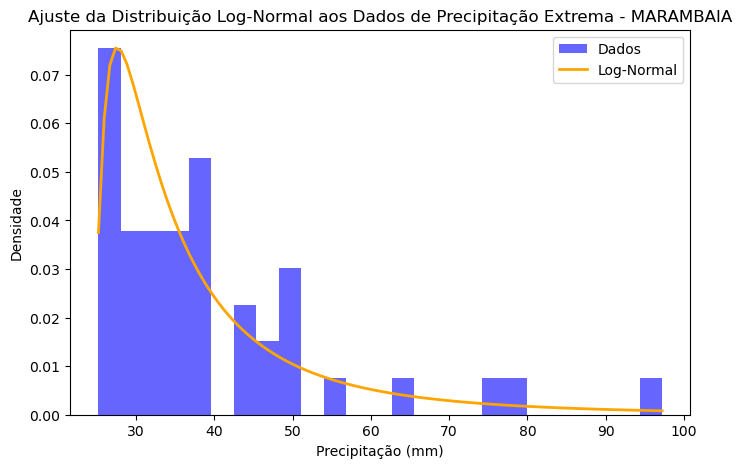

Teste KS para Log-Normal: KS=0.0764, p-valor=0.9323


In [292]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


dados_chuva_extrema = df[(df['Precip'] >= 25) & (df['ESTACAO'] == 'MARAMBAIA')]


# Selecionar os dados de precipitação
dados = dados_chuva_extrema['Precip']  # Certifique-se de que é uma série numérica
dados = dados.dropna()  # Remove valores NaN
dados = dados[np.isfinite(dados)]  # Remove valores infinitos

# Ajustar distribuição Log-Normal
dist = stats.lognorm
params = dist.fit(dados)  # Ajuste dos parâmetros
shape, loc, scale = params  # Parâmetros da distribuição

# Exibir os parâmetros ajustados
print(f"Parâmetros da Log-Normal:")
print(f" - shape (σ): {shape:.4f}")
print(f" - loc (μ deslocado): {loc:.4f}")
print(f" - scale (exp(μ)): {scale:.4f}")

# Criar histograma normalizado
plt.figure(figsize=(8, 5))
contagem, bins, _ = plt.hist(dados, bins=25, density=True, alpha=0.6, color='b', label='Dados')

# Gerar valores da PDF
x = np.linspace(min(dados), max(dados), 100)
pdf = dist.pdf(x, *params)

# Ajustar escala da PDF para o histograma
pdf *= max(contagem) / max(pdf)

# Plotar curva ajustada
plt.plot(x, pdf, color='orange', lw=2, label='Log-Normal')

plt.xlabel("Precipitação (mm)")
plt.ylabel("Densidade")
plt.legend()
plt.title("Ajuste da Distribuição Log-Normal aos Dados de Precipitação Extrema - MARAMBAIA")
plt.show()

# Teste de Kolmogorov-Smirnov para Log-Normal
ks_stat, p_value = stats.kstest(dados, 'lognorm', args=params)
print(f"Teste KS para Log-Normal: KS={ks_stat:.4f}, p-valor={p_value:.4f}")


In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


dados_chuva_extrema = df[(df['Precip'] >= 25) & (df['ESTACAO'] == 'VILA_MILITAR')]


# Selecionar os dados de precipitação
dados = dados_chuva_extrema['Precip']  # Certifique-se de que é uma série numérica
dados = dados.dropna()  # Remove valores NaN
dados = dados[np.isfinite(dados)]  # Remove valores infinitos

# Ajustar distribuição Log-Normal
dist = stats.lognorm
params = dist.fit(dados)  # Ajuste dos parâmetros
shape, loc, scale = params  # Parâmetros da distribuição

# Exibir os parâmetros ajustados
print(f"Parâmetros da Log-Normal:")
print(f" - shape (σ): {shape:.4f}")
print(f" - loc (μ deslocado): {loc:.4f}")
print(f" - scale (exp(μ)): {scale:.4f}")

# Criar histograma normalizado
plt.figure(figsize=(8, 5))
contagem, bins, _ = plt.hist(dados, bins=25, density=True, alpha=0.6, color='b', label='Dados')

# Gerar valores da PDF
x = np.linspace(min(dados), max(dados), 100)
pdf = dist.pdf(x, *params)

# Ajustar escala da PDF para o histograma
pdf *= max(contagem) / max(pdf)

# Plotar curva ajustada
plt.plot(x, pdf, color='orange', lw=2, label='Log-Normal')

plt.xlabel("Precipitação (mm)")
plt.ylabel("Densidade")
plt.legend()
plt.title("Ajuste da Distribuição Log-Normal aos Dados de Precipitação Extrema - VILA MILITAR")
plt.show()

# Teste de Kolmogorov-Smirnov para Log-Normal
ks_stat, p_value = stats.kstest(dados, 'lognorm', args=params)
print(f"Teste KS para Log-Normal: KS={ks_stat:.4f}, p-valor={p_value:.4f}")


Parâmetros da Log-Normal:
 - shape (σ): 0.7672
 - loc (μ deslocado): 23.2846
 - scale (exp(μ)): 9.0055


In [ ]:
import matplotlib.pyplot as plt

# Filtrar dados para a estação "JACAREPAGUA" e precipitação >= 25
dados_chuva_extrema = df[(df['Precip'] >= 25) & (df['ESTACAO'] == 'JACAREPAGUA')]

# Criar o histograma com mais bins
plt.figure(figsize=(10, 6))
plt.hist(dados_chuva_extrema['Precip'], bins=25, edgecolor='black')  # Aumentei para 50 bins
plt.title('Histograma - Precipitação Total Horária (mm) (Valores >= 25) na Estação JACAREPAGUA')
plt.xlabel('Precipitação (mm)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Filtrar dados para a estação "JACAREPAGUA" e precipitação >= 25
dados_chuva_extrema = df[(df['Precip'] >= 25) & (df['ESTACAO'] == 'MARAMBAIA')]

# Criar o histograma com mais bins
plt.figure(figsize=(10, 6))
plt.hist(dados_chuva_extrema['Precip'], bins=25, edgecolor='black')  # Aumentei para 50 bins
plt.title('Histograma - Precipitação Total Horária (mm) (Valores >= 25) na Estação MARAMBAIA')
plt.xlabel('Precipitação (mm)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Filtrar dados para a estação "JACAREPAGUA" e precipitação >= 25
dados_chuva_extrema = df[(df['Precip'] >= 25) & (df['ESTACAO'] == 'VILA_MILITAR')]

# Criar o histograma com mais bins
plt.figure(figsize=(10, 6))
plt.hist(dados_chuva_extrema['Precip'], bins=25, edgecolor='black')  # Aumentei para 50 bins
plt.title('Histograma - Precipitação Total Horária (mm) (Valores >= 25) na Estação VILA MILITAR')
plt.xlabel('Precipitação (mm)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
dados_chuva_extrema.head(2)

In [ ]:
dados_chuva_extrema['Precip'].describe()

In [ ]:


# Criar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(dados_chuva_extrema['Precip'])
plt.title('Boxplot de CHUVA')
plt.ylabel('Quantidade de Chuva extrema (Valores maiores que 25 mm hora)')
plt.xlabel('CHUVA')
plt.show()


# Matriz de correlação. 



In [ ]:
df.columns

In [ ]:
variaveis = ['Precip','VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO','VARIACAO SEGUNDA HORA ANTERIOR PRESSAO','VARIACAO TERCEIRA HORA ANTERIOR PRESSAO',
             'VARIACAO QUARTA HORA ANTERIOR PRESSAO', 'VARIACAO QUINTA HORA ANTERIOR PRESSAO', 'VARIACAO SEXTA HORA ANTERIOR PRESSAO'
            
            ]

In [ ]:
# Calcula a matriz de correlação
correlation_matrix = dados_chuva[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))



# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas e variação de pressão.')


# Exibe o gráfico
plt.show()

In [ ]:
# Calcula a matriz de correlação
correlation_matrix = dados_chuva_extrema[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas extremas e variação de pressão.')

# Exibe o gráfico
plt.show()

In [ ]:
dados_chuva_extrema.columns

In [ ]:

            
variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Pres_Atm_max','Pres_Atm_min']

pressao = df[variaveis]


In [ ]:
# Substitui os valores -9999 por NaN
pressao.replace(-9999, np.nan, inplace=True)

# Conta a quantidade de valores nulos em cada coluna
missing_values = pressao.isnull().sum()

# Exibe a quantidade de valores nulos
print(missing_values)

# Total de valores nulos no DataFrame
total_missing_values = pressao.isnull().sum().sum()
print("Total de valores nulos no DataFrame:", total_missing_values)

In [ ]:
pressao.head(5)

In [ ]:
len(pressao)

In [ ]:
pressao_nulos = pressao[pressao['Precip'].isnull()]

In [ ]:
pressao_nulos.head()

In [ ]:
len(pressao_nulos)

In [ ]:
29821/ 565872 # 5% dos dados de precipitação são nulos. 



In [ ]:
pressao_sem_nulos = pressao.dropna(subset=['Precip'])

In [ ]:
pressao_sem_nulos.head()

# criando variavel de maior diferença

In [ ]:
# Eu preciso criar a seguinte variável chamada : A MAIOR DIFERENÇA DE PRESSÃO 2 HORAS ATRAS. 

Eu tenho as seguintes variaveis: Dt_Hr que mede a data e hora, ESTACAO que é onde foi feita a medição, Pres_Atm_max que foi a maior medição de pressão na hora
anterior e Pres_Atm_min que foi a minima.

Os dados são ordenados por Dt_Hr e ESTACAO, eu preciso pegar a maior diferenca entre Pres_Atm_max e Pres_Atm_min das duas horas anteriores.

a era precisa estar em uma sequencia de medição, exemplo, 2007-05-18 18:00:00 e 2007-05-18 19:00:00, se não estiver, não vale e precisa 






In [ ]:
pressao_sem_nulos = pressao_sem_nulos.sort_values(by=['ESTACAO', 'Dt_Hr'])

In [ ]:
# Função para calcular a maior diferença de pressão nas duas horas anteriores
def calcular_maior_diferenca(grupo):
    grupo = grupo.copy()
    
    grupo['MAIOR_DIFERENCA_PRESSAO_2H_ATRAS'] = (
        grupo['Pres_Atm_max'].rolling(window=2, min_periods=2).max() - 
        grupo['Pres_Atm_min'].rolling(window=2, min_periods=2).min()
    )

    grupo['MAIOR_DIFERENCA_PRESSAO_3H_ATRAS'] = (
        grupo['Pres_Atm_max'].rolling(window=3, min_periods=3).max() - 
        grupo['Pres_Atm_min'].rolling(window=3, min_periods=3).min()
    )
    
    return grupo


In [ ]:

# Aplica a função para cada grupo de estação

pressao_sem_nulos = pressao_sem_nulos.reset_index(drop=True)

pressao_sem_nulos = pressao_sem_nulos.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)



In [ ]:
pressao_sem_nulos.head()

In [ ]:
1013.2 - 1010.0

# Avaliando correlação de pressão: FORTE DE COPACABANA.

In [ ]:
COPACABANA = df[df['ESTACAO'] == 'FORTE_COPACABANA']


In [ ]:
# Variáveis que quero usar. 
variaveis = ['Dt_Hr', 'ESTACAO','Precip', 'Pres_Atm_max','Pres_Atm_min',
             'VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO',
             'VARIACAO SEGUNDA HORA ANTERIOR PRESSAO',
             'VARIACAO TERCEIRA HORA ANTERIOR PRESSAO']

COPACABANA = COPACABANA[variaveis]




In [ ]:
# Tirando esses nulos.

# Substitui os valores -9999 por NaN
COPACABANA.replace(-9999, np.nan, inplace=True)

# Conta a quantidade de valores nulos em cada coluna
missing_values = COPACABANA.isnull().sum()

# Exibe a quantidade de valores nulos
print(missing_values)

# Total de valores nulos no DataFrame
total_missing_values = COPACABANA.isnull().sum().sum()
print("Total de valores nulos no DataFrame:", total_missing_values)



In [ ]:
len(COPACABANA)

In [ ]:
5682/153768 , # 3% dos dados são nulos. 

In [ ]:
COPACABANA = COPACABANA.dropna(subset=['Precip'])

In [ ]:
# Função para calcular a maior diferença de pressão nas duas horas anteriores
def calcular_maior_diferenca(grupo):
    grupo = grupo.copy()
    
    grupo['MAIOR_DIFERENCA_PRESSAO_2H_ATRAS'] = (
        grupo['Pres_Atm_max'].rolling(window=2, min_periods=2).max() - 
        grupo['Pres_Atm_min'].rolling(window=2, min_periods=2).min()
    )

    grupo['MAIOR_DIFERENCA_PRESSAO_3H_ATRAS'] = (
        grupo['Pres_Atm_max'].rolling(window=3, min_periods=3).max() - 
        grupo['Pres_Atm_min'].rolling(window=3, min_periods=3).min()
    )
    
    return grupo

COPACABANA = COPACABANA.reset_index(drop=True)

COPACABANA = COPACABANA.groupby('ESTACAO').apply(calcular_maior_diferenca).reset_index(drop=True)


In [ ]:
COPACABANA.head()

In [ ]:


COPACABANA_CHUVA = COPACABANA[(COPACABANA['Precip'] > 0) & (COPACABANA['Precip'] < 25)]

COPACABANA_CHUVA_EXTREMA = COPACABANA[COPACABANA['Precip'] >= 25]



In [ ]:
COPACABANA_CHUVA.head(1)

In [ ]:
COPACABANA_CHUVA_EXTREMA.head(1)

In [ ]:
variaveis = ['Precip','VARIACAO PRIMEIRA HORA ANTERIOR PRESSAO','VARIACAO SEGUNDA HORA ANTERIOR PRESSAO','VARIACAO TERCEIRA HORA ANTERIOR PRESSAO',
             'MAIOR_DIFERENCA_PRESSAO_2H_ATRAS','MAIOR_DIFERENCA_PRESSAO_3H_ATRAS'
            
            ]

In [ ]:
# Calcula a matriz de correlação
correlation_matrix = COPACABANA_CHUVA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas normais e variação de pressão.')

# Exibe o gráfico
plt.show()

In [ ]:
# Calcula a matriz de correlação
correlation_matrix = COPACABANA_CHUVA_EXTREMA[variaveis].corr()

# Configura o tamanho da figura
plt.figure(figsize=(10, 8))

# Gera o heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Correlação entre chuvas extremas e variação de pressão.')

# Exibe o gráfico





























































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































plt.show()